<a href="https://colab.research.google.com/github/alfadder/ProgForDataAnalysis/blob/main/Programming_For_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell imports essential libraries for data manipulation, analysis, and visualization, including pandas, numpy, sklearn, matplotlib, plotly, and seaborn.

# Task 1: Data Selection & Handling

In [ ]:
import pandas as pd
import numpy as np
import os
import sklearn as sk
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

These commands configure global Git user settings (name and email), which are typically used for committing changes to a repository.

In [ ]:
! git config --global user.name "alfadder" # replace with your username that you used to create the Github account
! git config --global user.email "alfadder@gmail.com" # and the email id which you have used to create account

This cell defines Python variables for the GitHub username and the repository name. These variables will be used in subsequent Git operations.

In [ ]:
username = "alfadder" #replace with your own user name
repo = "ProgForDataAnalysis"  #replace with your required repo

This command clones the specified GitHub repository into your Colab environment, making the repository's files accessible.

In [ ]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'ProgForDataAnalysis'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 18 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 3.11 MiB | 5.07 MiB/s, done.
Resolving deltas: 100% (7/7), done.


This command changes the current working directory to the newly cloned repository, allowing direct access to its contents.

In [ ]:
%cd {repo}

/content/ProgForDataAnalysis


This command lists the files and directories within the current working directory (the cloned repository), confirming the successful cloning.

In [ ]:
%ls

Programming_For_Data_Analysis.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv


This cell reads multiple city-specific CSV files, combines them into a single pandas DataFrame named `df`, saves the combined data to a new CSV file, and then displays the first few rows of the combined DataFrame.

In [ ]:
import pandas as pd
import glob

city_files = glob.glob("*.csv")
all_cities_data = []

for file_name in city_files:
  city_df = pd.read_csv(file_name)
  all_cities_data.append(city_df)
  print(f"Loaded: {file_name}")

combined_data = pd.concat(all_cities_data, ignore_index=True)
combined_data.to_csv("all_cities_combined.csv", index=False)
print(f"SUCCESS: Combined {len(city_files)} city files into one file with {len(combined_data)} total rows")
print("The combined file is saved as: all_cities_combined.csv")

df= pd.read_csv('all_cities_combined.csv')
df


Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
SUCCESS: Combined 4 city files into one file with 140256 total rows
The combined file is saved as: all_cities_combined.csv


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,11.0,11.0,2.0,2.0,200.0,99.0,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling
140252,35061,2017,2,28,20,13.0,13.0,2.0,2.0,200.0,101.0,10.9,1009.0,-14.0,0.0,N,2.1,Dingling
140253,35062,2017,2,28,21,9.0,14.0,2.0,2.0,200.0,102.0,9.5,1009.4,-13.0,0.0,N,1.5,Dingling
140254,35063,2017,2,28,22,10.0,12.0,2.0,2.0,200.0,97.0,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling


# 2.1.Data Understanding

This code calculates and displays the count of unique values in the 'station' column of the `df` DataFrame, showing how many entries exist for each station.

In [ ]:
stations = df['station'].value_counts()
stationdescribe = df['station'].describe()
stationinfo = pd.DataFrame(stations)
stationsdatatype = df['station'].dtypes

print("station data type")
print(stationsdatatype)
print("\nDescription of the 'station' column:")
print(stationinfo)
print("\nData type of the 'station' column:")
print(stationsdatatype)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")



station data type
object

Description of the 'station' column:
          count
station        
Gucheng   35064
Huairou   35064
Dongsi    35064
Dingling  35064

Data type of the 'station' column:
object
Number of rows: 140256
Number of columns: 20


### Explanation of 'station' column analysis

The output from 'df['station'].value_counts()', 'df['station'].describe()`, and 'df['station'].dtypes' provides the following insights:

*   Station Counts: There are 4 unique stations (Gucheng, Huairou, Dongsi, Dingling), and each station has 35,064 entries. This means the dataset is balanced across these locations. due to the fact it covers the same period of time and nay missing data has been cprrectly handled and estimated.
*   Data TYpe: The 'station' column is of 'object' data type, which is appropriate for string data.
*   Description: The 'describe()' output confirms the count, number of unique values, and identifies 'Gucheng' as the most frequent station, though all stations appear equally often in terms of row count. This indicates that all selected stations have an equal amount of hourly data.

This confirms the successful merging of data from the four selected stations.

# 2.2.Data preprocessing:

This cell creates a new 'date' column by combining the 'year', 'month', 'day', and 'hour' columns into a single datetime object, which is crucial for time-series analysis.

In [ ]:
import pandas as pd
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00


This cell generates a heatmap to visually represent missing values across the DataFrame before any imputation, providing an overview of data completeness. It also shows descriptive statistics for all numerical columns.

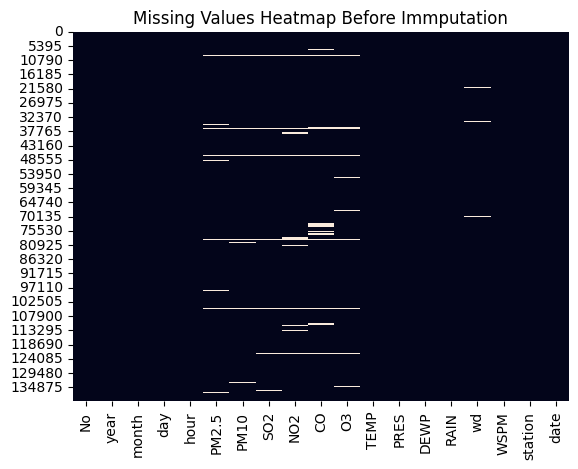

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137128.000000,137889.000000,137376.000000,135114.000000,132224.000000,136498.000000,140081.00000,140083.000000,140079.000000,140087.000000,140108.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.433458,101.156036,14.449835,42.468751,1143.995561,60.793546,13.41694,1009.184718,2.200587,0.064194,1.677524,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.90000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,400.000000,17.000000,3.00000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,52.000000,78.000000,6.000000,34.000000,800.000000,51.000000,14.40000,1008.800000,2.600000,0.000000,1.300000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,107.000000,143.000000,18.000000,61.134550,1400.000000,85.000000,23.10000,1017.300000,15.000000,0.000000,2.100000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.60000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.994830,90.945361,20.020561,33.603041,1076.211778,56.080125,11.48208,10.349554,13.873769,0.807661,1.254475,NaN


In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap Before Immputation')
plt.show()
df.describe()

This code identifies all numerical columns in the DataFrame that contain missing values, which are the target columns for the subsequent imputation steps.

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
missing_values_count = numerical_df.isnull().sum()
numerical_cols_with_missing_values = missing_values_count[missing_values_count > 0].index.tolist()

print("Numerical columns with missing values:")
print(numerical_cols_with_missing_values)

Numerical columns with missing values:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']


This cell performs a two-step grouped mean imputation for numerical columns. It first fills missing values by grouping by 'station', 'year', and 'month', and then specifically imputes any remaining 'CO' missing values by grouping by 'station' and 'month'.

In [ ]:
for col in numerical_cols_with_missing_values:
    df[col] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])[col].transform(lambda x: x.fillna(x.mean()))

# Impute remaining 'CO' values by station and month for cases where entire months were missing
if 'CO' in numerical_cols_with_missing_values and df['CO'].isnull().any():
    df['CO'] = df.groupby(['station', df['date'].dt.month])['CO'].transform(lambda x: x.fillna(x.mean()))

print("Missing values after grouped mean imputation:")
print(df[numerical_cols_with_missing_values].isnull().sum())

Missing values after grouped mean imputation:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


This code prints a summary of all remaining missing values across the entire DataFrame after the numerical imputation steps, highlighting columns that still have nulls (e.g., 'wd').

In [ ]:
print("Remaining missing values after grouped mean imputation:")
print(df.isnull().sum())

Remaining missing values after grouped mean imputation:
No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2          0
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd         679
WSPM         0
station      0
date         0
dtype: int64


This cell displays the complete `df` DataFrame after the numerical imputation, allowing you to view the current state of the data.

In [ ]:
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date
0,1,2013,3,1,0,6.0,18.0,5.000000,76.913542,800.000000,88.000000,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng,2013-03-01 00:00:00
1,2,2013,3,1,1,6.0,15.0,5.000000,76.913542,800.000000,88.000000,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng,2013-03-01 01:00:00
2,3,2013,3,1,2,5.0,18.0,38.202755,76.913542,700.000000,52.000000,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,20.0,6.000000,76.913542,1624.285513,59.124166,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng,2013-03-01 03:00:00
4,5,2013,3,1,4,5.0,17.0,5.000000,76.913542,600.000000,73.000000,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,11.0,11.0,2.000000,2.000000,200.000000,99.000000,11.7,1008.9,-13.3,0.0,NNE,1.3,Dingling,2017-02-28 19:00:00
140252,35061,2017,2,28,20,13.0,13.0,2.000000,2.000000,200.000000,101.000000,10.9,1009.0,-14.0,0.0,N,2.1,Dingling,2017-02-28 20:00:00
140253,35062,2017,2,28,21,9.0,14.0,2.000000,2.000000,200.000000,102.000000,9.5,1009.4,-13.0,0.0,N,1.5,Dingling,2017-02-28 21:00:00
140254,35063,2017,2,28,22,10.0,12.0,2.000000,2.000000,200.000000,97.000000,7.8,1009.6,-12.6,0.0,NW,1.4,Dingling,2017-02-28 22:00:00


This cell defines a list of column names (`gas_columns`) that represent various gas measurements, preparing for specific operations on these columns.

In [ ]:
gas_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
print("Identified gas columns:")
print(gas_columns)

Identified gas columns:
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']


This code selects the defined `gas_columns`, rounds their values to one decimal place, and displays the resulting formatted DataFrame, providing a clean view of the gas measurement data.

In [ ]:
formatted_gas_data = df[gas_columns].round(1)
print("Formatted gas measurement columns (rounded to 1 decimal place):")
formatted_gas_data

Formatted gas measurement columns (rounded to 1 decimal place):


,PM2.5,PM10,SO2,NO2,CO,O3
0,6.0,18.0,5.0,76.9,800.0,88.0
1,6.0,15.0,5.0,76.9,800.0,88.0
2,5.0,18.0,38.2,76.9,700.0,52.0
3,6.0,20.0,6.0,76.9,1624.3,59.1
4,5.0,17.0,5.0,76.9,600.0,73.0
...,...,...,...,...,...,...
140251,11.0,11.0,2.0,2.0,200.0,99.0
140252,13.0,13.0,2.0,2.0,200.0,101.0
140253,9.0,14.0,2.0,2.0,200.0,102.0
140254,10.0,12.0,2.0,2.0,200.0,97.0


This cell performs a two-step grouped mode imputation for the categorical 'wd' column. It first fills missing values by grouping by 'station', 'year', and 'month', and then by 'station' and 'month' for any remaining nulls, ensuring 'wd' is fully imputed.

In [ ]:
print("Missing values in 'wd' before imputation:")
print(df['wd'].isnull().sum())

# Impute missing values in 'wd' by grouping by 'station', 'year', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.year, df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

# Impute remaining missing values in 'wd' by grouping by 'station', 'month' using the mode
df['wd'] = df.groupby(['station', df['date'].dt.month])['wd'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan))

print("\nMissing values in 'wd' after grouped mode imputation:")
print(df['wd'].isnull().sum())

print("\nRemaining missing values in the entire DataFrame:")
print(df.isnull().sum())

Missing values in 'wd' before imputation:
679

Missing values in 'wd' after grouped mode imputation:
0

Remaining missing values in the entire DataFrame:
No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
date       0
dtype: int64


Removing Duplicates in the dataframe - there are no duplicates in this dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

Featured Engineering

In [ ]:
# Extract day of the week (Monday=0, Sunday=6)
df['day_of_week'] = df['date'].dt.dayofweek

# Create a binary flag for weekend (Saturday=5, Sunday=6)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

print("New temporal features added to DataFrame (first 5 rows):")
display(df[['date', 'day_of_week', 'is_weekend']].head())


New temporal features added to DataFrame (first 5 rows):


,date,day_of_week,is_weekend
0,2013-03-01 00:00:00,4,0
1,2013-03-01 01:00:00,4,0
2,2013-03-01 02:00:00,4,0
3,2013-03-01 03:00:00,4,0
4,2013-03-01 04:00:00,4,0


### Feature Engineering: Simplified Air Quality Index (AQI) & Analysis

To provide a more comprehensive view of air quality, we calculate a simplified Air Quality Index (AQI) primarily based on **PM2.5** concentrations, using common breakpoints. This allows for a single, more intuitive metric. The function `calculate_simplified_aqi_pm25` maps PM2.5 values to qualitative AQI categories (`'Good'`, `'Moderate'`, `'Unhealthy for Sensitive Groups'`, `'Unhealthy'`, `'Very Unhealthy'`, `'Hazardous'`).

After creating the `AQI_PM25_Category` column, we then analyze its distribution across different days of the week. This involves calculating the proportion of each AQI category for every day and visualizing it using a stacked bar chart. This helps in identifying weekly patterns or trends in overall air quality.

# 2.3.Statistical/Computational Analysis & Visualisation

This cell displays a heatmap of missing values for the final DataFrame, which should be entirely blank if all imputations were successful. It also provides descriptive statistics for the fully imputed dataset.

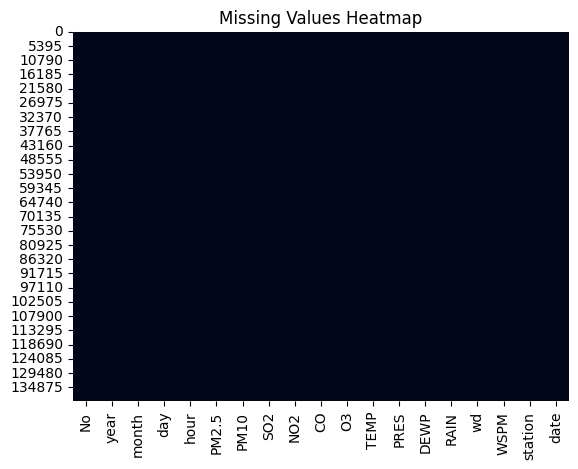

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,date
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.418775,101.142820,14.447132,42.427050,1149.245679,61.039722,13.405744,1009.191585,2.187762,0.064145,1.677643,2015-03-01 11:29:59.999999744
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000,2013-03-01 00:00:00
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,19.000000,33.000000,2.000000,16.000000,500.000000,17.000000,3.000000,1000.800000,-9.400000,0.000000,0.900000,2014-03-01 05:45:00
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,53.000000,79.000000,6.000000,34.000000,900.000000,51.000000,14.400000,1008.900000,2.600000,0.000000,1.300000,2015-03-01 11:30:00
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,142.000000,18.000000,61.000000,1400.000000,86.000000,23.100000,1017.300000,14.900000,0.000000,2.100000,2016-02-29 17:15:00
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,994.000000,500.000000,276.000000,10000.000000,1071.000000,41.600000,1042.000000,29.100000,52.100000,12.900000,2017-02-28 23:00:00
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.212436,90.272532,19.902119,33.148722,1052.332571,55.560721,11.483923,10.347359,13.875769,0.807177,1.253877,NaN


In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()
df.describe()

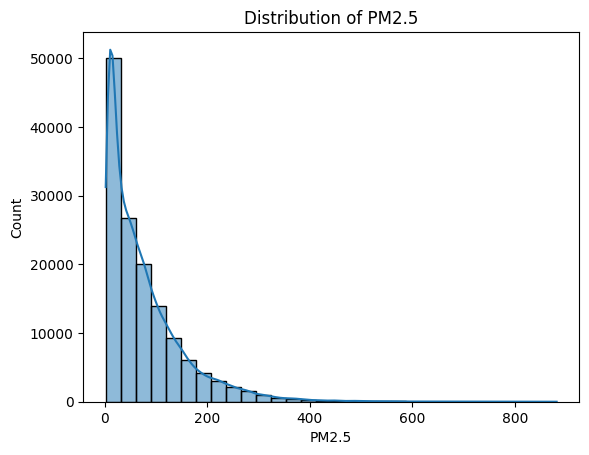

In [ ]:
import seaborn as sns
sns.histplot(data=df, x="PM2.5", bins=30, kde=True)
title = "Distribution of PM2.5"
plt.title(title)
plt.show()

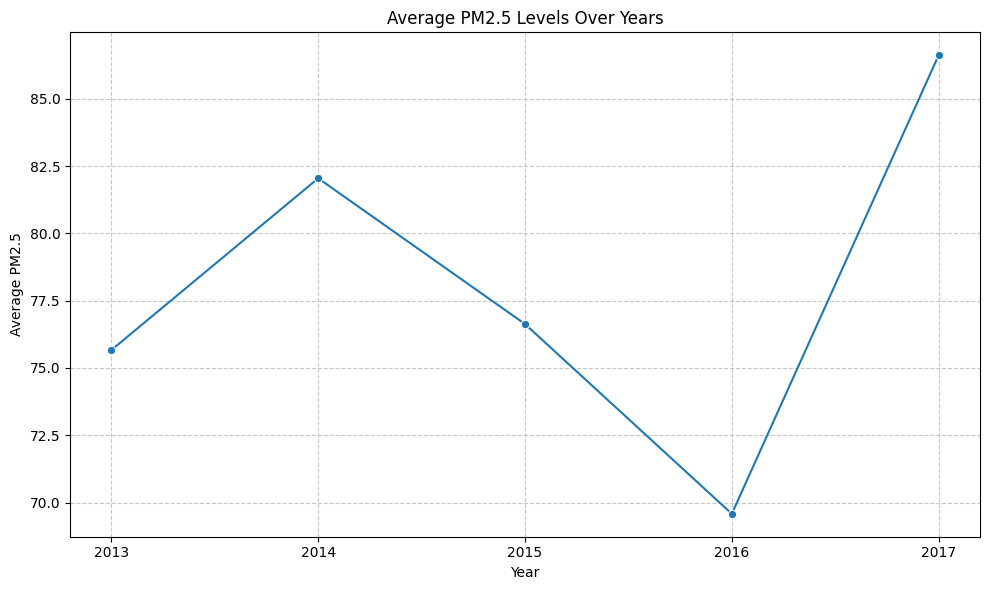

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_avg_pm25 = df.groupby('year')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='PM2.5', data=yearly_avg_pm25, marker='o')
plt.title('Average PM2.5 Levels Over Years')
plt.xlabel('Year')
plt.ylabel('Average PM2.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_avg_pm25['year'].unique())
plt.tight_layout()
plt.show()

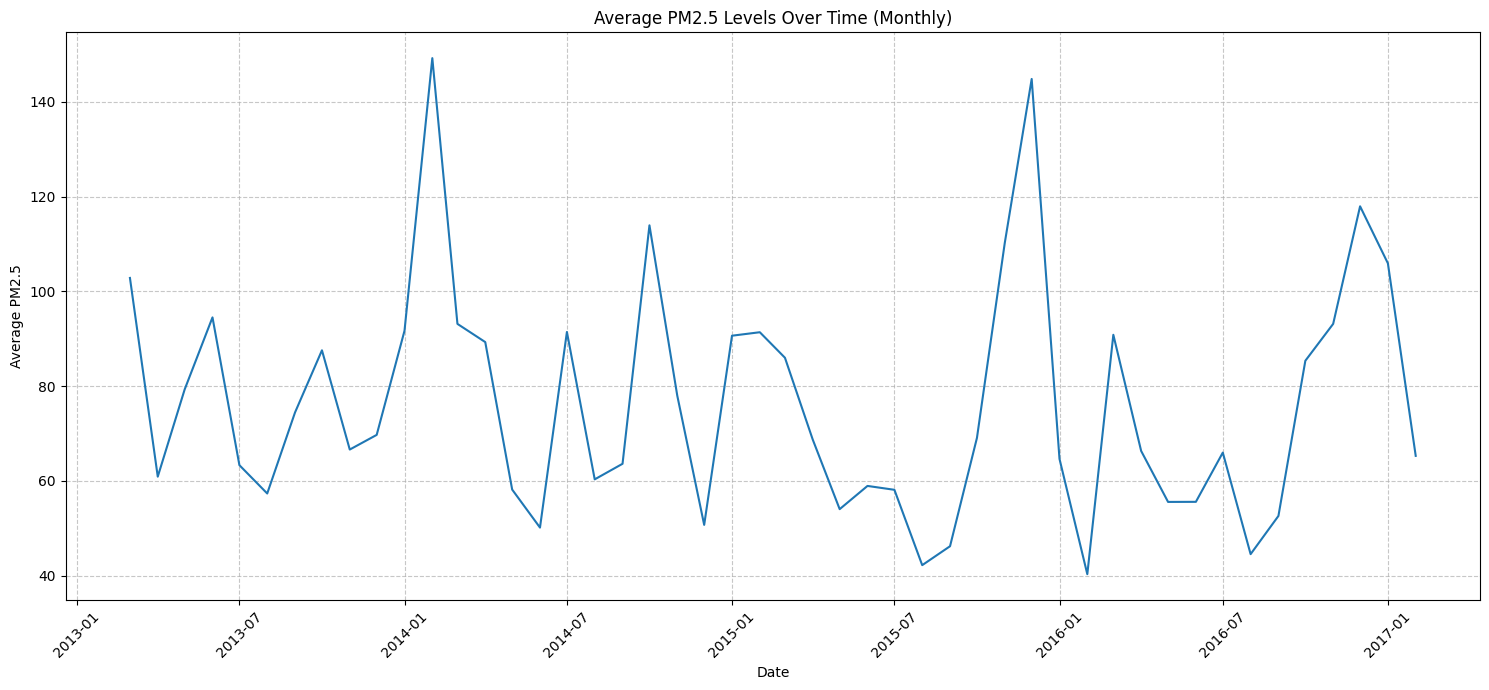

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'month_start_date' column for plotting each month across years
df['month_start_date'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Group by this new monthly date and calculate the mean PM2.5
monthly_pm25_over_time = df.groupby('month_start_date')['PM2.5'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(x='month_start_date', y='PM2.5', data=monthly_pm25_over_time)
plt.title('Average PM2.5 Levels Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Average PM2.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_avg_gas_levels = df.groupby(['station', 'month_start_date'])[gas_columns].mean().reset_index()
print("Monthly Average Gas Levels by Station:")
monthly_avg_gas_levels.head()

Monthly Average Gas Levels by Station:


,station,month_start_date,PM2.5,PM10,SO2,NO2,CO,O3
0,Dingling,2013-03-01,95.705645,110.311231,24.358088,48.238364,1015.409859,68.141251
1,Dingling,2013-04-01,55.206506,80.148936,13.725471,26.967120,635.846726,73.853376
2,Dingling,2013-05-01,71.402266,114.093220,17.413140,28.586733,766.922619,97.733500
3,Dingling,2013-06-01,85.520950,87.280112,7.829724,20.992806,1145.575403,81.439421
4,Dingling,2013-07-01,54.012676,56.859773,4.191483,15.649809,759.668666,81.595652


In [ ]:
fig = px.line(
    monthly_avg_gas_levels,
    x='month_start_date',
    y=gas_columns,
    color='station',
    facet_col='station',
    facet_col_wrap=2,
    title='Monthly Average Gas Levels Over Time by Station',
    labels={
        'month_start_date': 'Date',
        'value': 'Average Level',
        'variable': 'Gas Type'
    }
)
fig.update_layout(height=800, width=1000)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()


In [ ]:
for gas_type in gas_columns:
    fig = px.line(
        monthly_avg_gas_levels,
        x='month_start_date',
        y=gas_type,
        color='station',
        title=f'Monthly Average {gas_type} Levels Over Time by Station',
        labels={
            'month_start_date': 'Date',
            gas_type: f'Average {gas_type} Level',
            'station': 'Station'
        }
    )
    fig.update_layout(height=500, width=800) # Adjust plot size for better readability
    fig.show()


# Task
Create a simplified Air Quality Index (AQI) based on PM2.5 concentrations, categorize the air quality, and then visualize the monthly proportions of these AQI categories for each station in a 2x2 grid of stacked bar charts. Finally, summarize the observed monthly patterns and differences in air quality across the stations.

## Calculate Simplified AQI

### Subtask:
Define the `calculate_simplified_aqi_pm25` function and apply it to the 'PM2.5' column in the DataFrame to create a new 'AQI_PM25_Category' column, classifying air quality based on PM2.5 concentrations.


**Reasoning**:
Define the `calculate_simplified_aqi_pm25` function, apply it to the 'PM2.5' column to create 'AQI_PM25_Category', and then display the head of the DataFrame to verify the new column.



In [ ]:
def calculate_simplified_aqi_pm25(pm25_value):
    if 0 <= pm25_value <= 12.0:
        return 'Good'
    elif 12.1 <= pm25_value <= 35.4:
        return 'Moderate'
    elif 35.5 <= pm25_value <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif 55.5 <= pm25_value <= 150.4:
        return 'Unhealthy'
    elif 150.5 <= pm25_value <= 250.4:
        return 'Very Unhealthy'
    elif pm25_value >= 250.5:
        return 'Hazardous'
    else:
        return 'Invalid'

df['AQI_PM25_Category'] = df['PM2.5'].apply(calculate_simplified_aqi_pm25)
display(df[['PM2.5', 'AQI_PM25_Category']].head())

,PM2.5,AQI_PM25_Category
0,6.0,Good
1,6.0,Good
2,5.0,Good
3,6.0,Good
4,5.0,Good


**Reasoning**:
Calculate the monthly proportions of each AQI category for every station and prepare the data for visualization.



In [ ]:
monthly_aqi_proportions = df.groupby(['station', 'month_start_date', 'AQI_PM25_Category']).size().unstack(fill_value=0)
monthly_aqi_proportions = monthly_aqi_proportions.apply(lambda x: x / x.sum(), axis=1)

# Ensure all AQI categories are present in the correct order for consistent plotting
aqi_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
for col in aqi_order:
    if col not in monthly_aqi_proportions.columns:
        monthly_aqi_proportions[col] = 0
monthly_aqi_proportions = monthly_aqi_proportions[aqi_order]

monthly_aqi_proportions = monthly_aqi_proportions.reset_index()
print("Monthly AQI proportions by station:")
display(monthly_aqi_proportions.head())

Monthly AQI proportions by station:


AQI_PM25_Category,station,month_start_date,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
0,Dingling,2013-03-01,0.205645,0.125000,0.114247,0.315860,0.161290,0.077957
1,Dingling,2013-04-01,0.302778,0.165278,0.143056,0.311111,0.075000,0.002778
2,Dingling,2013-05-01,0.107527,0.176075,0.159946,0.465054,0.071237,0.020161
3,Dingling,2013-06-01,0.061111,0.256944,0.118056,0.418056,0.111111,0.034722
4,Dingling,2013-07-01,0.134409,0.348118,0.165323,0.295699,0.056452,0.000000


**Reasoning**:
Visualize the monthly proportions of AQI categories for each station using a 2x2 grid of stacked bar charts, making sure to use consistent colors and clear labels.



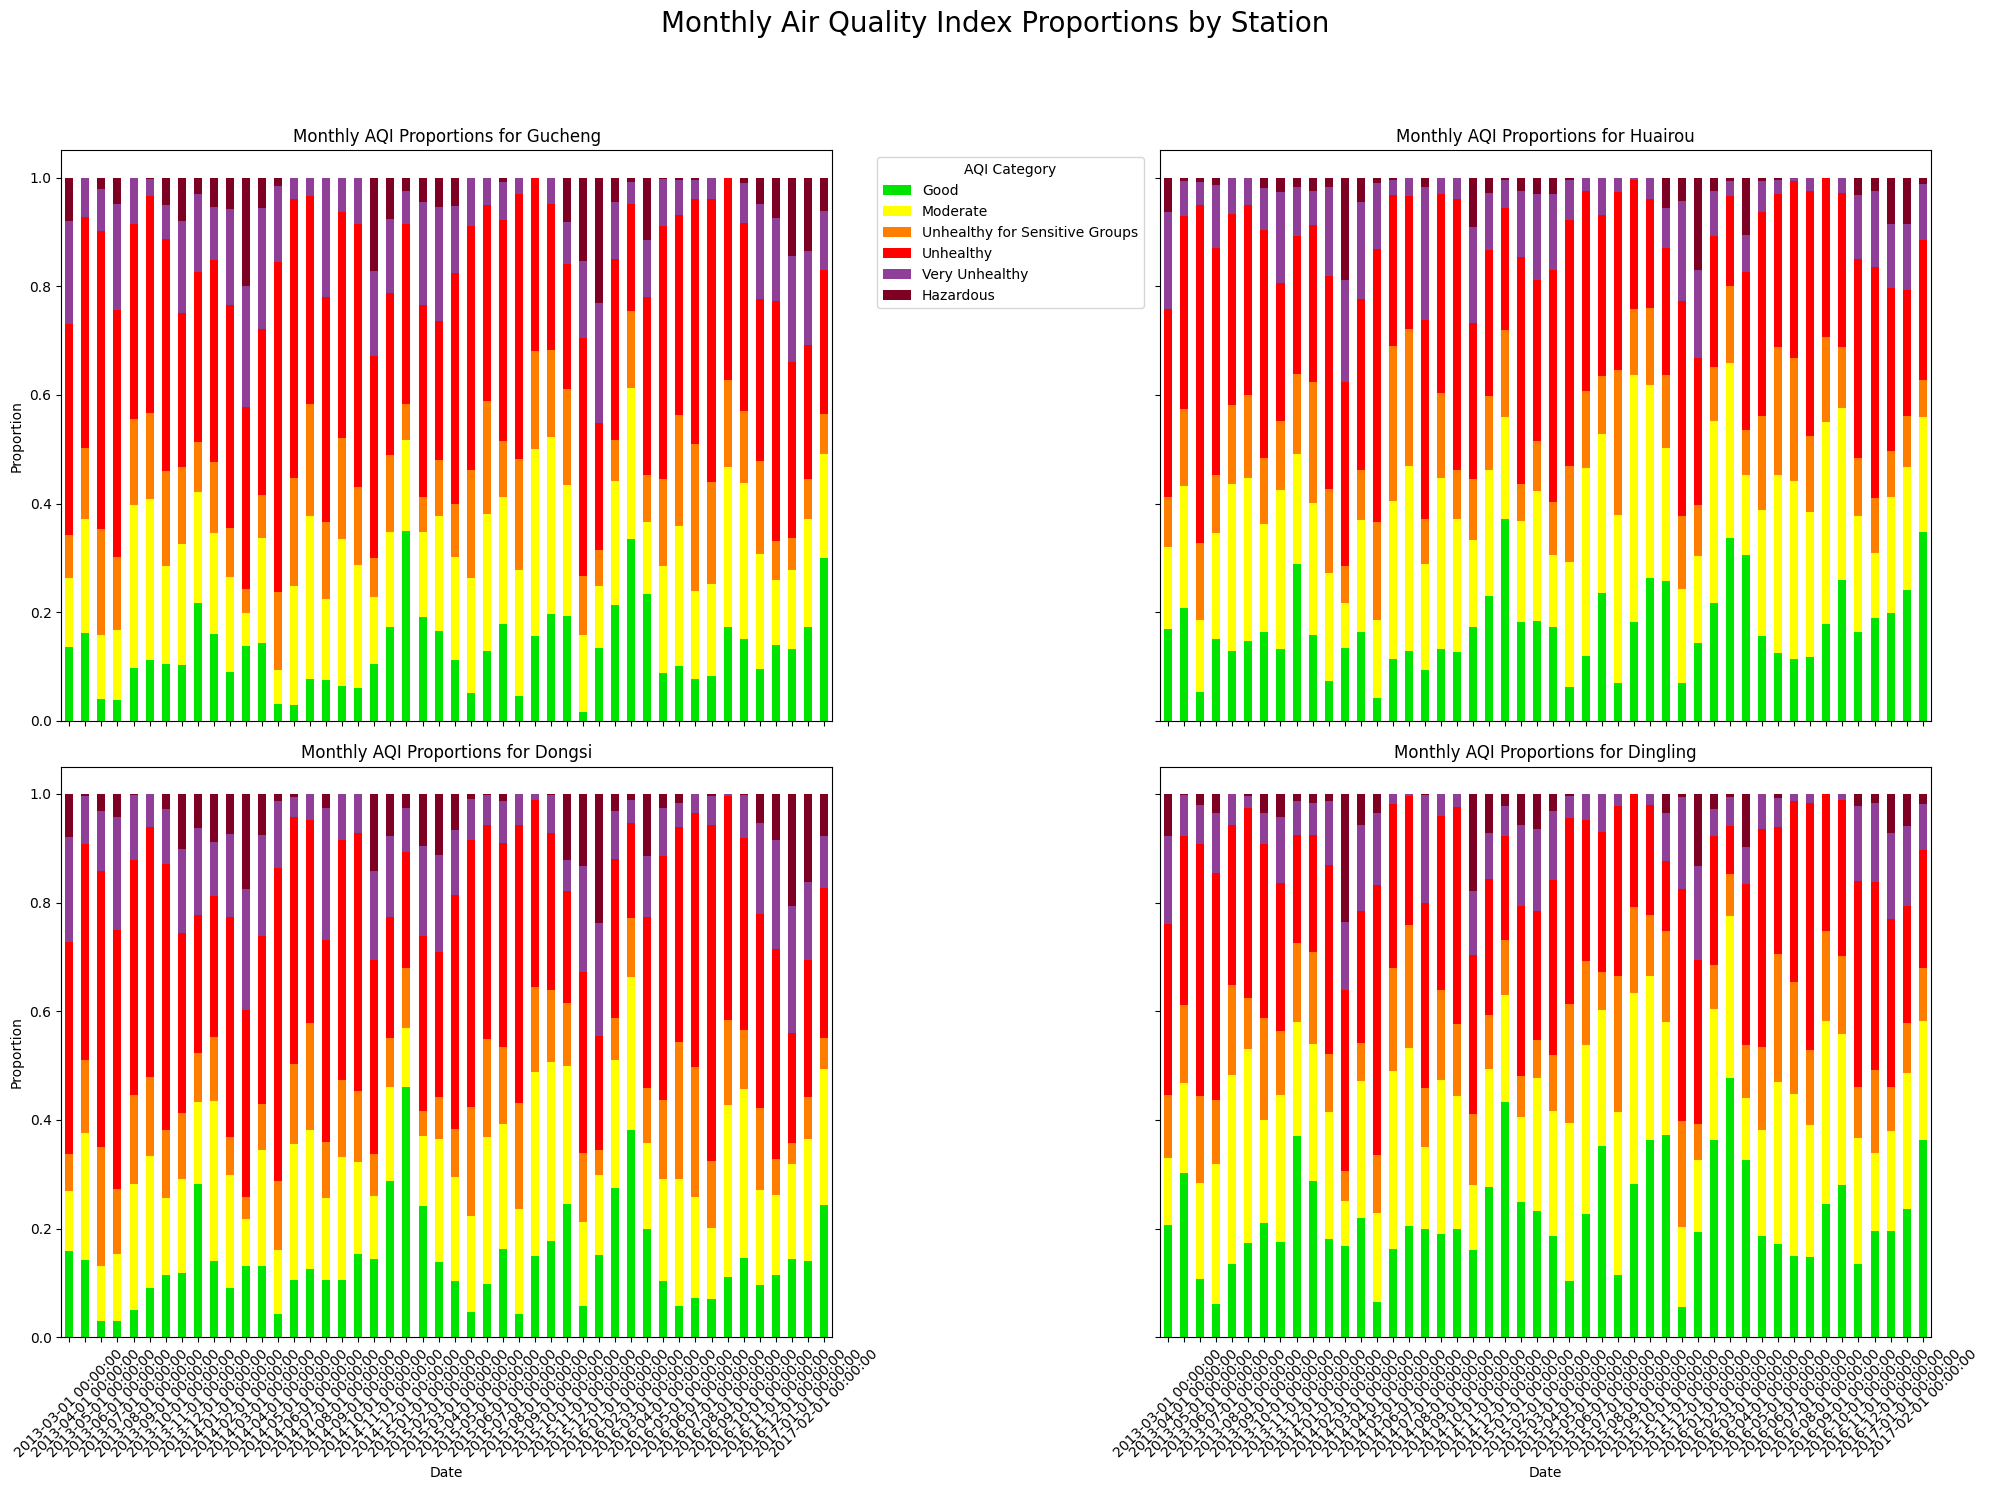

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define colors for AQI categories for consistent plotting
aqi_colors = {
    'Good': '#00e400',  # Green
    'Moderate': '#ffff00', # Yellow
    'Unhealthy for Sensitive Groups': '#ff7e00', # Orange
    'Unhealthy': '#ff0000', # Red
    'Very Unhealthy': '#8f3f97', # Purple
    'Hazardous': '#7e0023'  # Maroon
}

stations_list = df['station'].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 15), sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations_list):
    station_data = monthly_aqi_proportions[monthly_aqi_proportions['station'] == station]
    station_data_pivot = station_data.set_index('month_start_date')[aqi_order]

    # Plot stacked bar chart for each station
    station_data_pivot.plot(kind='bar', stacked=True, ax=axes[i], color=[aqi_colors[cat] for cat in aqi_order])
    axes[i].set_title(f'Monthly AQI Proportions for {station}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=45)

    # Place legend only on the first subplot to avoid clutter
    if i == 0:
        axes[i].legend(title='AQI Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.suptitle('Monthly Air Quality Index Proportions by Station', fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()
